In [6]:
import os
import time
import json
import pickle
import pandas as pd
import numpy as np
from functools import partial
import joblib

from datetime import datetime
from tqdm import tqdm
from dotenv import load_dotenv
from pathlib import Path
from scipy.sparse import load_npz, vstack

In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

import torch

import optuna
import mlflow
from databricks.sdk import WorkspaceClient

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

Define path variables

In [9]:
representation_type = "integrated_syntactic_graph"
classification_type = "embedding_cosine_similarity"
developer_initials = "JP"

In [10]:
current_dir = Path.cwd()
env_path = current_dir.parent.parent / "conf" / "local" / ".env"
results_path = current_dir.parent.parent / "results" / "graph"

train_data_full_cleaned_path = current_dir.parent.parent / "data" /  "01_processed" / "pan20-authorship-verification-training-large-cleaned.jsonl"
validation_data_full_cleaned_path = current_dir.parent.parent / "data" /  "01_processed" / "pan20-authorship-verification-validation-large-cleaned.jsonl"
test_data_full_cleaned_path = current_dir.parent.parent / "data" /  "01_processed" / "pan21-authorship-verification-test-cleaned.jsonl"

train_data_isg1_path = current_dir.parent.parent / "data" / "01_processed" / "training-vectors-isg1.npz"
train_data_isg2_path = current_dir.parent.parent / "data" / "01_processed" / "training-vectors-isg2.npz"

val_data_isg1_path = current_dir.parent.parent / "data" / "01_processed" / "val-vectors-isg1.npz"
val_data_isg2_path = current_dir.parent.parent / "data" / "01_processed" / "val-vectors-isg2.npz"

test_data_isg1_path = current_dir.parent.parent / "data" / "01_processed" / "test-vectors-isg1.npz"
test_data_isg2_path = current_dir.parent.parent / "data" / "01_processed" / "test-vectors-isg2.npz"

Connect to databricks for logging results

In [11]:
load_dotenv(env_path)

w = WorkspaceClient()   
print("Connected to:", w.config.host)

mlflow.set_tracking_uri("databricks")
mlflow.autolog()

2025/12/28 23:57:24 WARNING mlflow.utils.autologging_utils: MLflow sklearn autologging is known to be compatible with 1.4.0 <= scikit-learn, but the installed version is 1.3.2. If you encounter errors during autologging, try upgrading / downgrading scikit-learn to a compatible version, or try upgrading MLflow.


Connected to: https://dbc-1ea3ad0e-f504.cloud.databricks.com


2025/12/28 23:57:24 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2025/12/28 23:57:24 WARNING mlflow.utils.autologging_utils: MLflow statsmodels autologging is known to be compatible with 0.14.1 <= statsmodels, but the installed version is 0.14.0. If you encounter errors during autologging, try upgrading / downgrading statsmodels to a compatible version, or try upgrading MLflow.
2025/12/28 23:57:25 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.


What are GPU are the experiments run on

In [12]:
!nvidia-smi

/usr/bin/sh: line 1: nvidia-smi: command not found


In [13]:
running_on_gpu = torch.cuda.is_available()

In [14]:
if running_on_gpu:
    gpu_name = torch.cuda.get_device_name(0)
    gpu_props = torch.cuda.get_device_properties(0)
    gpu_vram_gb = round(gpu_props.total_memory / (1024**3), 2)
else:
    gpu_name = "CPU"
    gpu_props = "N/A"
    gpu_vram_gb = 0

Empty the GPU from previous experiments

In [15]:
import gc
import torch
torch.cuda.empty_cache()
gc.collect()

3

In [16]:
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

Classification threshold constant specification

In [17]:
classification_thresholds = [x/1000 for x in range(200, 999)]

# Load dataset

### Load training data

In [14]:
train_data_file_size = os.path.getsize(train_data_full_cleaned_path)
train_data = []

with open(train_data_full_cleaned_path, 'r') as f:
    with tqdm(total=train_data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            train_data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(train_data)} items.")

Loading data: 100%|██████████| 11.3G/11.3G [00:24<00:00, 467MB/s]


Successfully loaded 273301 items.


In [15]:
train_data_df = pd.DataFrame(train_data)

Prepare dataset for cosine embedding loss

In [16]:
train_data_df.head(10)

,id,pair,same
0,e05b9c0b-88a1-5608-b7e8-ab1fc6b78dc1,"[Well, ever since you and Kurt broke up youve ...",False
1,12f73a20-cdf3-58df-b5bb-9392eec9b486,"[The thing is, Ryouga has no reason to run aft...",False
2,d82c6764-451b-544c-8711-c139e9349c56,"[Ehhhh nah, its silly' Its my job to listen to...",True
3,876b8380-9260-5427-93e8-dc31155c3edd,"[Glaring at the arrogant spark, Always asks va...",False
4,357e8471-35b9-50b4-9ac0-286ac0e8b101,[Runa limped across the small space to an open...,False
5,6b39fe22-409f-5329-9fe1-ddf4a70bedd1,"[And thats retired Commander, if you please St...",False
6,76ed2017-0c9f-580f-83b1-5a041a8169ec,[Meet you downstairs in twenty minutes I say w...,True
7,fd8deb2e-06de-5c92-9a4c-927891c53657,"[Since Ive seen so many others do so, Im going...",False
8,3ce5e811-a57c-5fbf-9f9a-2ee636e50be6,[party Eishi exclaimed Omi shook his head and ...,False
9,25a17cd2-6b01-5fba-99ef-e631e56e181d,[After a few moments she found that Red was ri...,False


##### Load the integrated graph vectors for training

In [17]:
train_vectors1 = load_npz(train_data_isg1_path)
train_vectors2 = load_npz(train_data_isg2_path)
train_embeddings = (train_vectors1, train_vectors2)

### Load validation data

In [18]:
val_data_file_size = os.path.getsize(validation_data_full_cleaned_path)
val_data = []

with open(validation_data_full_cleaned_path, 'r') as f:
    with tqdm(total=val_data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            val_data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(val_data)} items.")

Loading data: 100%|██████████| 103M/103M [00:00<00:00, 448MB/s] 


Successfully loaded 2500 items.


In [19]:
val_data_df = pd.DataFrame(val_data)

##### Load the integrated graph vectors for validation

In [21]:
val_vectors1 = load_npz(val_data_isg1_path)
val_vectors2 = load_npz(val_data_isg2_path)
val_embeddings = (val_vectors1, val_vectors2)

### Combine the training and validation data

##### Combine the dataframes

In [21]:
train_data_df = pd.concat(
    [train_data_df, val_data_df],
    axis=0,
    ignore_index=True
)

##### Combine the vectors

In [22]:
train_embeddings = (
    vstack([train_embeddings[0], val_embeddings[0]]),
    vstack([train_embeddings[1], val_embeddings[1]])
)

### Load testing data

In [22]:
test_data_file_size = os.path.getsize(test_data_full_cleaned_path)
test_data = []

with open(test_data_full_cleaned_path, 'r') as f:
    with tqdm(total=test_data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            test_data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(test_data)} items.")

Loading data: 100%|██████████| 826M/826M [00:01<00:00, 515MB/s] 


Successfully loaded 19999 items.


In [23]:
test_data_df = pd.DataFrame(test_data)

##### Load the integrated graph vectors for training

In [24]:
test_vectors1 = load_npz(test_data_isg1_path)
test_vectors2 = load_npz(test_data_isg2_path)
test_embeddings = (test_vectors1, test_vectors2)

# Set up evaluation functions

Evaluate model function

In [42]:
def compute_similarities(test_data_df, test_embeddings):
    
    def cosine_sim(a, b):
        return cosine_similarity(a, b)[0, 0]
    
    start_time = time.time()
    verification_results = []

    for i in tqdm(test_data_df.index, desc="Processing rows"):
        
        resulting_df_row = {}
        resulting_df_row['id']  = test_data_df.loc[i, 'id']
        resulting_df_row['actual_result'] = test_data_df.loc[i, 'same']
        
        text1_embedding  = test_embeddings[0][i]
        text2_embedding = test_embeddings[1][i]

        cosine_similarity_score = cosine_sim(text1_embedding, text2_embedding)
        resulting_df_row["cosine_similarity"] = cosine_similarity_score

        verification_results.append(resulting_df_row)

    result_df = pd.DataFrame(verification_results)
    print("--- Execution Time: %s seconds ---" % round(time.time() - start_time, 2))

    return result_df

Evaluation function

In [43]:
def evaluate_results(y_true, y_pred, average='binary'):
    accuracy = round(accuracy_score(y_true, y_pred)*100, 2)
    precision = round(precision_score(y_true, y_pred, average=average)*100, 2)
    recall = round(recall_score(y_true, y_pred, average=average)*100, 2)
    f1 = round(f1_score(y_true, y_pred, average=average)*100, 2)
    return accuracy, precision, recall, f1

Optimal threshold search

In [44]:
def evaluate_classification_thresholds(result_df, classification_thresholds):
    results = []
    y_embeddings = result_df['cosine_similarity']
    y_true = result_df['actual_result']
    for threshold in classification_thresholds:
        y_pred = (result_df["cosine_similarity"] >= threshold).astype(int)
        accuracy, precision, recall, f1 = evaluate_results(y_true, y_pred)
        results.append({
            "threshold": threshold,
            "accuracy" : accuracy,
            "precision" : precision,
            "recall" : recall,
            "f1" : f1
        })
    return pd.DataFrame(results)

Create histogram of F1 score for different thresholds

In [45]:
def plot_f1_vs_threshold(results_df):
    plt.figure(figsize=(9, 5))
    plt.plot(results_df["threshold"], results_df["f1"], linewidth=2)
    plt.xlabel("Threshold")
    plt.ylabel("F1 Score")
    plt.title("F1 Score vs Classification Threshold")
    plt.grid(True)
    plt.tight_layout()
    return plt.gcf()

Create the confusion matrix

In [46]:
def create_confusion_matrix(y_true, y_pred, labels=[False, True]):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    
    cm_fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, 
                fmt='d', 
                cmap='Blues',
                xticklabels=labels, 
                yticklabels=labels, 
                ax=ax,
                cbar=False)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix: {model_id}')
    return cm

# Find the top threshold

In [47]:
result_df = compute_similarities(train_data_df, val_embeddings)
result_df.head()

Processing rows: 100%|██████████| 2500/2500 [00:08<00:00, 301.72it/s]

--- Execution Time: 8.29 seconds ---


,id,actual_result,cosine_similarity
0,b2ae0880-dfc8-5348-becb-5b9cbb331e3c,True,0.999750
1,1ba2349a-7342-5829-920b-64038c9fe815,False,0.999487
2,96dc6b60-1ad6-56b0-b035-00e6f057bedb,False,0.953764
3,431f2e19-76ab-5524-b2b2-93e86ffdb6f8,True,0.941308
4,50b24ce9-e2b0-5687-8f5d-cbe49e76ce0c,True,0.999704


Evaluate the results against different thresholds

In [48]:
threshold_results_df = evaluate_classification_thresholds(result_df, classification_thresholds)

Evaluate thresholds

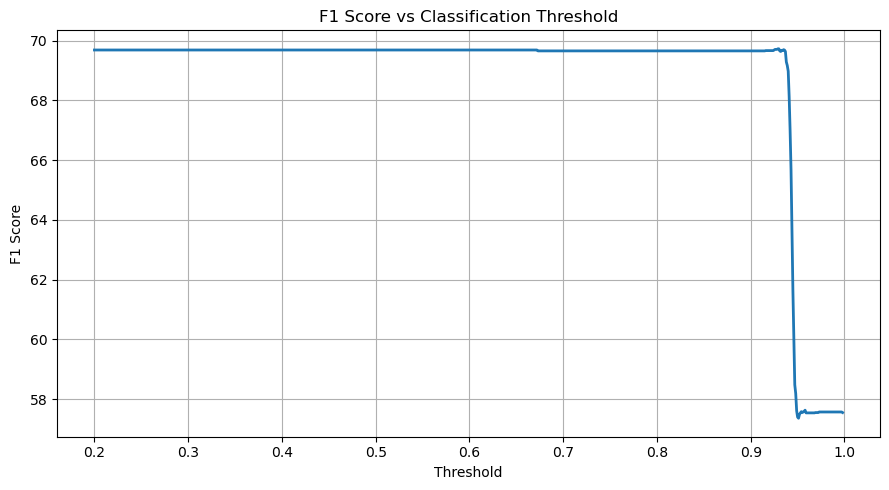

In [49]:
f1_threshold_histogram_fig = plot_f1_vs_threshold(threshold_results_df)
f1_threshold_histogram_fig.show()

Print top 5 results

In [50]:
sorted_threshold_results_df = threshold_results_df.sort_values("f1", ascending=False)
top5_results = sorted_threshold_results_df.head(5)

print("Top 5 thresholds by F1:")
print(top5_results)

Top 5 thresholds by F1:
     threshold  accuracy  precision  recall     f1
730      0.930     53.60      53.55   99.93  69.73
729      0.929     53.60      53.55   99.93  69.73
728      0.928     53.56      53.53   99.93  69.71
727      0.927     53.56      53.53   99.93  69.71
726      0.926     53.56      53.53   99.93  69.71


Pick the best result and compute y_pred

In [43]:
top_threshold = top5_results.iloc[0]["threshold"]
top_threshold

0.937

# Evaluate the model

In [44]:
result_df = compute_similarities(test_data_df, test_embeddings)

Processing rows: 100%|██████████| 100/100 [00:00<00:00, 201.24it/s]

--- Execution Time: 0.5 seconds ---


In [45]:
y_true = result_df['actual_result']
y_pred = (result_df["cosine_similarity"] >= top_threshold).astype(int).values

best_accuracy, best_precision, best_recall, best_f1 = evaluate_results(y_true, y_pred)

Create the confusion matrix

Text(0.5, 1.0, 'Confusion Matrix: integrated_syntactic_graph embedding_cosine_similarity')

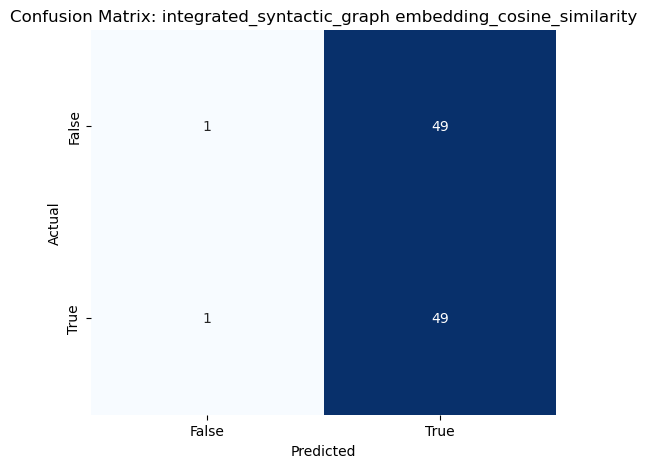

In [47]:
labels = [False, True] 
cm = confusion_matrix(y_true, y_pred, labels=labels)

cm_fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=labels, 
            yticklabels=labels, 
            ax=ax,
            cbar=False)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix: {representation_type} {classification_type}')

Log model information + metrics + results table + confusion matrix

In [50]:
mlflow.set_experiment("/Users/jiripokorny455@gmail.com/JP_authorship_verification_dt")
with mlflow.start_run(run_name=f"{developer_initials}_results_{representation_type}_{classification_type}"):
    mlflow.log_param("gpu_name", gpu_name)
    mlflow.log_param("gpu_vram_gb", gpu_vram_gb)
    
    mlflow.log_param("representation_type", representation_type)
    mlflow.log_param("classification_type", classification_type)

    mlflow.log_param("classification_thresholds", classification_thresholds)

    mlflow.log_table(data=result_df, artifact_file="embedding_similarity_results-test_data.json")
    mlflow.log_table(data=threshold_results_df, artifact_file="results_for_different_thresholds-training_data.json")

    mlflow.log_metric("top_threshold", top_threshold)
    mlflow.log_metric("top_f1", best_f1)
    mlflow.log_metric("top_recall", best_recall)
    mlflow.log_metric("top_precision", best_precision)
    mlflow.log_metric("top_accuracy", best_accuracy)

    mlflow.log_figure(f1_threshold_histogram_fig, "f1_results_threshold_histogram-training_data.png")
    mlflow.log_figure(cm_fig, "confusion_matrix-test_data.png")

🏃 View run JP_results_integrated_syntactic_graph_embedding_cosine_similarity at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040/runs/1c1f4dd3ee734ac29e5e02263fdca4eb
🧪 View experiment at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040
